# Session 4 | LoRA、对齐与评测

---

**Day 2 下午 — 3.5 小时**

**学习目标：** 掌握 LoRA 微调 → 理解 DPO 对齐 → 学会模型评测 → 做出成本决策与模型选型

---

## 课程路线图

| 时间 | 内容 | 类型 |
|------|------|------|
| 0:00-0:10 | 为什么要 LoRA？GPU 显存成本表 | 讲解 |
| 0:10-0:35 | LoRA 从零实现 | 代码随讲 |
| 0:35-0:45 | **练习1**: 实现 LoRA forward | 练习 |
| 0:45-1:05 | 用 PEFT 库做真实 LoRA 微调 | 代码随讲 |
| 1:05-1:15 | **练习2**: 对比 rank 4/16/32 效果 | 练习 |
| 1:15-1:25 | 休息 | |
| 1:25-1:45 | 量化 + QLoRA：4-bit 微调 | 代码随讲 |
| 1:45-1:55 | **练习3**: 计算不同配置的 GPU 显存需求 | 练习 |
| 1:55-2:20 | DPO 对齐：“RLHF 太难，DPO 够用” | 代码随讲 |
| 2:20-2:30 | **练习4**: 跑 DPO 训练，对比输出风格 | 练习 |
| 2:30-2:50 | 评测：PPL + 任务准确率 + LLM-as-Judge | 代码随讲 |
| 2:50-3:00 | **练习5**: 用评测框架评估模型 | 练习 |
| 3:00-3:15 | 企业决策：模型选型指南 + 成本分析 | 讲解+讨论 |
| 3:15-3:25 | **练习6**: 给定场景，选微调策略并估成本 | 练习 |
| 3:25-3:30 | Day2 总结 | |

In [1]:
import os, warnings, logging
os.environ["HF_ENDPOINT"] = "https://hf-mirror.com"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
warnings.filterwarnings("ignore", message=".*tie_word_embeddings.*")
warnings.filterwarnings("ignore", message=".*UNEXPECTED.*")
logging.getLogger("transformers.modeling_utils").setLevel(logging.ERROR)

import sys
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath("__file__")), "utils"))
sys.path.insert(0, "utils")


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict, List, Optional, Tuple
from collections import defaultdict
import warnings, re, json, time, random
warnings.filterwarnings('ignore')

# --- CJK font support for matplotlib ---
plt.rcParams["font.sans-serif"] = ["Noto Sans CJK SC", "Microsoft YaHei", "SimHei", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams.update({
    "figure.dpi": 100,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "white",
})

torch.manual_seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")
if device == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using device: cpu


In [3]:
try:
    from transformers import AutoModelForCausalLM, AutoTokenizer, TrainingArguments, Trainer
    print("Transformers loaded!")
except ImportError:
    !pip install transformers accelerate -q
    from transformers import AutoModelForCausalLM, AutoTokenizer, TrainingArguments, Trainer

try:
    from peft import LoraConfig, get_peft_model, TaskType, PeftModel, prepare_model_for_kbit_training
    PEFT_AVAILABLE = True
    print("PEFT library loaded!")
except ImportError:
    PEFT_AVAILABLE = False
    print("PEFT not available - install with: pip install peft")

try:
    import bitsandbytes as bnb
    BNB_AVAILABLE = True
    print("bitsandbytes loaded (for quantization)!")
except Exception as e:
    BNB_AVAILABLE = False
    print(f"bitsandbytes not available: {e}")

Transformers loaded!
PEFT library loaded!
bitsandbytes not available: No module named 'bitsandbytes'


---

# Part 1：为什么要 LoRA？

## GPU 显存成本表

以 7B 模型为例，全量微调的资源开销：

```
┌─────────────────────────────────────────────────┐
│           GPU 显存需求（7B 模型）                │
├─────────────────────────────────────────────────┤
│  模型参数 (FP16)     ████████████  14 GB        │
│  梯度 (FP16)        ████████████  14 GB        │
│  Adam 优化器状态     ████████████████████████████│
│                     ████████████  56 GB        │
│                                                 │
│  总计: ~84 GB  → 相当于 3.5 张 RTX 3090!       │
│  RTX 3090 = 24 GB | RTX 4090 = 24 GB | A100=80G│
└─────────────────────────────────────────────────┘
```

> 一张消费级 GPU（16-24 GB）**装不下**！

## 解决方案对比

| 方法 | 显存节省 | 原理 | 消费级 GPU 可行？ |
|------|---------|------|:---:|
| **LoRA** | 可训练参数减少 ~100x | 低秩分解 (Low-Rank) | 可行 |
| **量化 (Quantization)** | 2-8x | 降低精度 | 可行 |
| **QLoRA** | 两者结合 | 量化+LoRA | **微调 7B!** |

**本节目标：在一张 8-24 GB 显卡上也能微调大模型。**

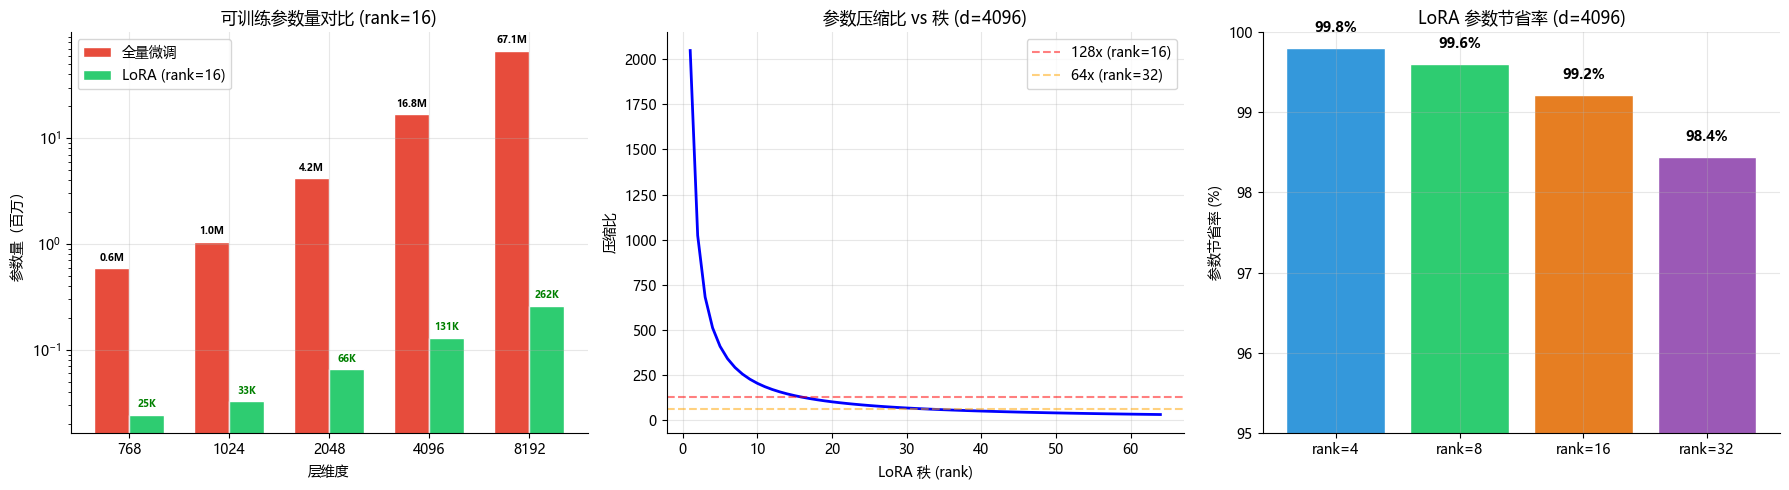

In [4]:
# 可视化：LoRA 参数节省

def calculate_params(d_in, d_out, rank):
    full_params = d_in * d_out
    lora_params = d_in * rank + rank * d_out
    return full_params, lora_params

dimensions = [768, 1024, 2048, 4096, 8192]
ranks = [4, 8, 16, 32]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: 参数量对比 (rank=16)
rank = 16
full_params = [d * d for d in dimensions]
lora_params = [d * rank + rank * d for d in dimensions]
x = np.arange(len(dimensions))
width = 0.35

bars1 = axes[0].bar(x - width/2, np.array(full_params)/1e6, width,
                     label='全量微调', color='#e74c3c', edgecolor='white')
bars2 = axes[0].bar(x + width/2, np.array(lora_params)/1e6, width,
                     label=f'LoRA (rank={rank})', color='#2ecc71', edgecolor='white')
for bar in bars1:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, h * 1.1,
                 f'{h:.1f}M', ha='center', va='bottom', fontsize=7, fontweight='bold')
for bar in bars2:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, h * 1.1,
                 f'{h*1000:.0f}K', ha='center', va='bottom', fontsize=7, fontweight='bold', color='green')
axes[0].set_xlabel('层维度')
axes[0].set_ylabel('参数量（百万）')
axes[0].set_xticks(x)
axes[0].set_xticklabels(dimensions)
axes[0].set_title('可训练参数量对比 (rank=16)')
axes[0].legend()
axes[0].set_yscale('log')

# Plot 2: 压缩比 vs rank
d = 4096
compression_ratios = []
for r in range(1, 65):
    full, lora = calculate_params(d, d, r)
    compression_ratios.append(full / lora)
axes[1].plot(range(1, 65), compression_ratios, 'b-', linewidth=2)
axes[1].axhline(y=128, color='r', linestyle='--', alpha=0.5, label='128x (rank=16)')
axes[1].axhline(y=64, color='orange', linestyle='--', alpha=0.5, label='64x (rank=32)')
axes[1].set_xlabel('LoRA 秩 (rank)')
axes[1].set_ylabel('压缩比')
axes[1].set_title(f'参数压缩比 vs 秩 (d={d})')
axes[1].legend()

# Plot 3: 不同 rank 的参数节省率
savings = []
for r in ranks:
    full, lora = calculate_params(4096, 4096, r)
    savings.append((1 - lora/full) * 100)
axes[2].bar(range(len(ranks)), savings, color=['#3498db', '#2ecc71', '#e67e22', '#9b59b6'],
            edgecolor='white')
axes[2].set_xticks(range(len(ranks)))
axes[2].set_xticklabels([f'rank={r}' for r in ranks])
axes[2].set_ylabel('参数节省率 (%)')
axes[2].set_title('LoRA 参数节省率 (d=4096)')
for i, s in enumerate(savings):
    axes[2].text(i, s + 0.2, f'{s:.1f}%', ha='center', fontweight='bold')
axes[2].set_ylim(95, 100)
plt.tight_layout()
plt.show()

## LoRA 核心公式

### 直觉理解

想象你有一本厚厚的百科全书（原始权重 $W$），现在需要为某个特定任务做笔记。你不需要重写整本书，只需要在旁边贴一张**小便签**（$\Delta W$）。LoRA 的核心思想就是：这张便签可以用两个更小的矩阵相乘来表示，因为任务相关的变化往往是"低秩"的——只涉及少数几个方向的调整。

LoRA 的关键思路：微调时，权重变化 $\Delta W$ 是**低秩 (low-rank)** 的。

$$W' = W + \Delta W = W + BA$$

其中 $B \in \mathbb{R}^{d \times r}$，$A \in \mathbb{R}^{r \times k}$，$r \ll \min(d, k)$。

前向传播公式：

$$y = Wx + BAx \cdot \frac{\alpha}{r}$$

**参数量节省**：以 LLaMA-7B 注意力投影为例：$d = k = 4096$，$r = 8$，则

$$\text{节省比} = 1 - \frac{r \times (d + k)}{d \times k} = 1 - \frac{8 \times 8192}{16777216} = 99.6\%$$

| 秩 $r$ | LoRA 参数量 | 全量参数量 | 节约比 |
|:---:|:---:|:---:|:---:|
| 4 | 32,768 | 16,777,216 | 99.8% |
| 8 | 65,536 | 16,777,216 | 99.6% |
| 16 | 131,072 | 16,777,216 | 99.2% |
| 64 | 524,288 | 16,777,216 | 96.9% |

**初始化策略：** A 用 Kaiming 初始化，B 初始化为零 → 训练开始时 $\Delta W = BA = 0$，不改变原模型行为。

In [5]:
class LoRALinear(nn.Module):
    """
    LoRA implementation for a Linear layer.
    y = Wx + (BA)x * scaling
    """
    def __init__(self, in_features: int, out_features: int, rank: int = 4,
                 alpha: float = 1.0, dropout: float = 0.0):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.rank = rank
        self.alpha = alpha
        self.scaling = alpha / rank      # 缩放因子，控制 LoRA 的影响强度

        # 原始冻结的线性层（不参与训练）
        self.linear = nn.Linear(in_features, out_features)
        self.linear.weight.requires_grad = False
        if self.linear.bias is not None:
            self.linear.bias.requires_grad = False

        # LoRA 低秩矩阵: A（降维）和 B（升维）
        self.lora_A = nn.Parameter(torch.empty(rank, in_features))    # 降维: in_features -> rank
        self.lora_B = nn.Parameter(torch.zeros(out_features, rank))   # 升维: rank -> out_features（初始为零）
        nn.init.kaiming_uniform_(self.lora_A, a=np.sqrt(5))           # A 用 Kaiming 初始化

        self.dropout = nn.Dropout(dropout) if dropout > 0 else nn.Identity()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # 原始输出（冻结权重，不计算梯度）
        original_output = self.linear(x)
        # LoRA 旁路: x -> 降维(A) -> 升维(B) -> 缩放
        lora_out = self.dropout(x)
        lora_out = F.linear(lora_out, self.lora_A)   # [batch, seq, rank] 降维
        lora_out = F.linear(lora_out, self.lora_B)   # [batch, seq, out]  升维
        return original_output + lora_out * self.scaling  # 原始输出 + LoRA 增量

    def merge_weights(self):
        """将 LoRA 权重合并到原始权重中（推理时用，无额外开销）"""
        with torch.no_grad():
            delta_w = (self.lora_B @ self.lora_A) * self.scaling
            self.linear.weight.add_(delta_w)

    def get_trainable_params(self) -> int:
        return self.lora_A.numel() + self.lora_B.numel()

    def get_frozen_params(self) -> int:
        p = self.linear.weight.numel()
        if self.linear.bias is not None:
            p += self.linear.bias.numel()
        return p

# 测试
layer = LoRALinear(512, 512, rank=8, alpha=16)
x = torch.randn(2, 10, 512)
y = layer(x)
print(f"Input:  {x.shape}")
print(f"Output: {y.shape}")
print(f"Trainable params: {layer.get_trainable_params():,}")   # 只有 LoRA 参数需要训练
print(f"Frozen params:    {layer.get_frozen_params():,}")       # 原始参数被冻结
print(f"Ratio: {layer.get_trainable_params()/layer.get_frozen_params()*100:.2f}%")

Input:  torch.Size([2, 10, 512])
Output: torch.Size([2, 10, 512])
Trainable params: 8,192
Frozen params:    262,656
Ratio: 3.12%


---

## 练习 1：实现 LoRA 前向传播（10 分钟）⭐⭐ 进阶

补全 `lora_forward` 函数，实现 LoRA 前向传播：`y = Wx + BAx * scaling`

**任务：**
1. 计算冻结权重的输出 `Wx`
2. 计算低秩旁路 `BAx * scaling`
3. 两者相加返回

**提示：**
- `F.linear(x, A)` 等价于 `x @ A.T`
- 先算 `x @ A.T`，再算结果 `@ B.T`，最后乘 `scaling`

**预期输出：** `All tests passed!`

In [6]:
# 练习 1：实现 LoRA 前向传播

def lora_forward(x, W, lora_A, lora_B, scaling):
    """LoRA 前向传播: y = Wx + BAx * scaling"""
    # ↓↓↓ 你的代码 ↓↓↓
    base = W(x)
    lora_out = F.linear(F.linear(x, lora_A), lora_B)
    return base + lora_out * scaling
    # ↑↑↑ 你的代码 ↑↑↑

In [7]:
# 验证
torch.manual_seed(42)
in_features, out_features, rank = 64, 64, 8
alpha = 16
scaling = alpha / rank

W = nn.Linear(in_features, out_features, bias=False)
x = torch.randn(1, 4, in_features)

lora_A = torch.randn(rank, in_features) * 0.01
lora_B = torch.zeros(out_features, rank)
y = lora_forward(x, W, lora_A, lora_B, scaling)
base = W(x)
if y is not None:
    assert (y - base).abs().max().item() < 1e-6, "B=0 时 LoRA 增量应为 0"

    lora_B = torch.randn(out_features, rank) * 0.01
    y = lora_forward(x, W, lora_A, lora_B, scaling=0.0)
    assert (y - base).abs().max().item() < 1e-6, "scaling=0 时增量应为 0"

    y = lora_forward(x, W, lora_A, lora_B, scaling)
    assert y.shape == (1, 4, out_features), f"形状不匹配: {y.shape}"
    assert torch.isfinite(y).all(), "输出含 NaN/Inf"
    print("All tests passed!")
else:
    print("lora_forward 返回了 None，请完成实现")

All tests passed!


上面我们从零实现了 LoRA 的前向传播，理解了“冻结原始权重 + 低秩旁路”的核心思想。下一步我们将使用 HuggingFace 的 **PEFT 库**，看看在实际项目中如何用几行代码就完成 LoRA 微调。

---

# Part 2：用 PEFT 库做真实 LoRA 微调

从零实现帮助理解原理，但实际项目中我们用 **PEFT (Parameter-Efficient Fine-Tuning)** 库。核心 API 只需 3 步：
1. `LoraConfig(...)` — 配置
2. `get_peft_model(model, config)` — 包装
3. 正常训练即可

In [8]:
# 加载中文 GPT-2 模型
model_name = "uer/gpt2-chinese-cluecorpussmall"

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForCausalLM.from_pretrained(model_name).to(device)

if tokenizer.pad_token is None:
    if tokenizer.eos_token is not None:
        tokenizer.pad_token = tokenizer.eos_token
    else:
        tokenizer.add_special_tokens({"pad_token": "[PAD]"})
        model.resize_token_embeddings(len(tokenizer))

model.config.pad_token_id = tokenizer.pad_token_id
model.generation_config.pad_token_id = tokenizer.pad_token_id

print(f"✅ 模型加载完成: {model_name}")
print(f"   参数量: {sum(p.numel() for p in model.parameters()):,}")


The following layers were not sharded: transformer.h.*.mlp.c_fc.weight, transformer.ln_f.weight, transformer.h.*.mlp.c_fc.bias, lm_head.weight, transformer.h.*.attn.c_attn.bias, transformer.wpe.weight, transformer.h.*.attn.c_proj.bias, transformer.h.*.attn.c_proj.weight, transformer.h.*.ln_2.weight, transformer.h.*.mlp.c_proj.weight, transformer.h.*.ln_2.bias, transformer.h.*.attn.c_attn.weight, transformer.h.*.mlp.c_proj.bias, transformer.wte.weight, transformer.h.*.ln_1.weight, transformer.ln_f.bias, transformer.h.*.ln_1.bias


✅ 模型加载完成: uer/gpt2-chinese-cluecorpussmall
   参数量: 118,295,040


In [9]:
if PEFT_AVAILABLE:
    # LoRA 配置 —— 只需要这 3 步就能给模型加上 LoRA
    lora_config = LoraConfig(
        task_type=TaskType.CAUSAL_LM,         # 任务类型: 因果语言模型（自回归生成）
        r=16,                                  # rank: 低秩矩阵的秩（越大表达力越强，但参数越多）
        lora_alpha=32,                         # alpha: 缩放因子（通常设为 rank 的 2 倍）
        lora_dropout=0.1,                      # dropout: 防止过拟合
        target_modules=["c_attn", "c_proj"],   # 要加 LoRA 的层（GPT-2 的注意力层）
        bias="none",                           # 不训练 bias
    )
    print("LoRA Configuration:")
    print(f"  Rank (r): {lora_config.r}")
    print(f"  Alpha: {lora_config.lora_alpha}")
    print(f"  Dropout: {lora_config.lora_dropout}")
    print(f"  Target modules: {lora_config.target_modules}")

    # 一行代码将 LoRA 注入模型
    lora_model = get_peft_model(model, lora_config)
    lora_model.print_trainable_parameters()    # 查看可训练参数占比（应该很小！）
else:
    print("PEFT not available. Skipping LoRA injection.")

LoRA Configuration:
  Rank (r): 16
  Alpha: 32
  Dropout: 0.1
  Target modules: {'c_attn', 'c_proj'}
trainable params: 1,622,016 || all params: 119,917,056 || trainable%: 1.3526


In [10]:
# 准备客服分类训练数据
ISSUE_LABELS = ["延迟发货", "退款申请", "地址修改", "物流异常", "售后咨询", "发票问题"]
ISSUE_PHRASES = {
    "延迟发货": ["迟迟未发货", "发货很久没消息", "订单一直待发货"],
    "退款申请": ["想申请退款", "希望退货退款", "申请退款处理"],
    "地址修改": ["想修改收货地址", "地址填错需要改", "收货地址需要调整"],
    "物流异常": ["物流一直不更新", "包裹疑似丢件", "物流状态异常"],
    "售后咨询": ["咨询售后流程", "售后政策想了解", "需要售后支持"],
    "发票问题": ["发票怎么开", "需要补开发票", "发票信息有误"],
}
NAME_POOL = ["张伟", "王芳", "李娜", "刘洋", "陈磊", "赵敏"]
EMAIL_DOMAINS = ["example.com", "mail.com", "email.cn"]
TEXT_TEMPLATES = [
    "订单{order_id}相关用户{name}邮箱{email}，反馈：{detail}。",
    "客户{name}（{email}）反馈订单{order_id}，情况：{detail}。",
]

def _random_email(rng): return f"{''.join(rng.choice('abcdefghijklmnopqrstuvwxyz') for _ in range(6))}@{rng.choice(EMAIL_DOMAINS)}"
def _random_order_id(rng): return f"OD{rng.randint(20240101,20241228)}-{rng.randint(1000,9999)}"
def _generate_record(rng):
    issue = rng.choice(ISSUE_LABELS)
    name, email, oid = rng.choice(NAME_POOL), _random_email(rng), _random_order_id(rng)
    text = rng.choice(TEXT_TEMPLATES).format(order_id=oid, name=name, email=email, detail=rng.choice(ISSUE_PHRASES[issue]))
    return {"text": text, "label": issue}

def _build_records(count, seed):
    rng = random.Random(seed)
    return [_generate_record(rng) for _ in range(count)]

def format_prompt(text): return f"文本：{text}\n类别："

TRAINING_DATA = _build_records(1200, seed=42)

class TextDataset(Dataset):
    def __init__(self, samples, tokenizer, max_length=128):
        self.samples, self.tokenizer, self.max_length = samples, tokenizer, max_length
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        s = self.samples[idx]
        prompt_ids = self.tokenizer.encode(format_prompt(s['text']), add_special_tokens=False)
        answer_ids = self.tokenizer.encode(s['label'], add_special_tokens=False)
        max_p = self.max_length - len(answer_ids)
        if max_p < 1:
            prompt_ids = prompt_ids[-max(1, self.max_length-1):]
            answer_ids = answer_ids[:1]
        elif len(prompt_ids) > max_p:
            prompt_ids = prompt_ids[-max_p:]
        input_ids = prompt_ids + answer_ids
        attn_mask = [1] * len(input_ids)
        labels = [-100] * len(prompt_ids) + answer_ids
        pad_len = self.max_length - len(input_ids)
        if pad_len > 0:
            input_ids += [self.tokenizer.pad_token_id] * pad_len
            attn_mask += [0] * pad_len
            labels += [-100] * pad_len
        return {'input_ids': torch.tensor(input_ids), 'attention_mask': torch.tensor(attn_mask), 'labels': torch.tensor(labels)}

dataset = TextDataset(TRAINING_DATA, tokenizer)
print(f"Training dataset: {len(dataset)} samples")
print(f"Example: {TRAINING_DATA[0]['text'][:60]}... -> {TRAINING_DATA[0]['label']}")

Training dataset: 1200 samples
Example: 订单OD20240310-9935相关用户张伟邮箱axihhe@email.cn，反馈：发票信息有误。... -> 发票问题


Starting LoRA Fine-tuning...


Epoch 1/1 | Loss: 0.0448 | Time: 519.1s

Training done! Final loss: 0.0000


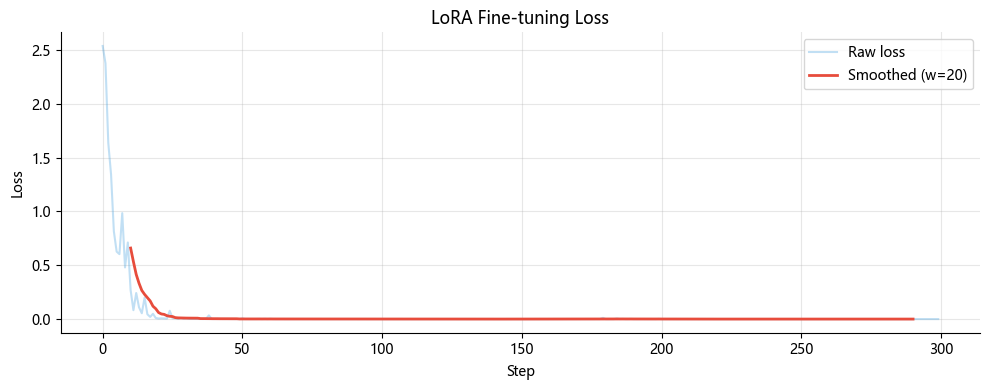

In [11]:
if PEFT_AVAILABLE:
    print("Starting LoRA Fine-tuning...")
    dataloader = DataLoader(dataset, batch_size=4, shuffle=True)
    optimizer = torch.optim.AdamW(lora_model.parameters(), lr=1e-3)

    lora_model.train()
    losses = []
    train_start = time.time()
    NUM_EPOCHS = 1

    for epoch in range(NUM_EPOCHS):
        epoch_loss = 0
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            outputs = lora_model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            losses.append(loss.item())
        avg_loss = epoch_loss / len(dataloader)
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Loss: {avg_loss:.4f} | Time: {time.time()-train_start:.1f}s")

    print(f"\nTraining done! Final loss: {losses[-1]:.4f}")

    # Plot
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(losses, alpha=0.3, color='#3498db', label='Raw loss')
    w = min(20, len(losses)//5) if len(losses) > 5 else 1
    if w > 1:
        smoothed = np.convolve(losses, np.ones(w)/w, mode='valid')
        ax.plot(range(w//2, w//2+len(smoothed)), smoothed, color='#e74c3c', linewidth=2, label=f'Smoothed (w={w})')
    ax.set_xlabel('Step'); ax.set_ylabel('Loss'); ax.set_title('LoRA Fine-tuning Loss')
    ax.legend(); plt.tight_layout(); plt.show()

---

## 练习 2：对比不同 rank 的效果（10 分钟）⭐⭐ 进阶

不同 rank（秩）决定 LoRA 的表达能力。完成以下对比实验。

**任务：**
1. 对每个 rank 值创建 `LoRALinear` 层
2. 训练 100 步，记录最终 MSE
3. 对比 rank=4, 16, 32 的拟合能力

**提示：**
- `LoRALinear(64, 64, rank=r, alpha=r*2)` 创建 LoRA 层
- `torch.optim.Adam(lora.parameters(), lr=0.01)` 创建优化器
- `F.mse_loss(lora(X_train), Y_train)` 计算损失

**预期：** rank 越大，MSE 越低（柱状图）

All tests passed!


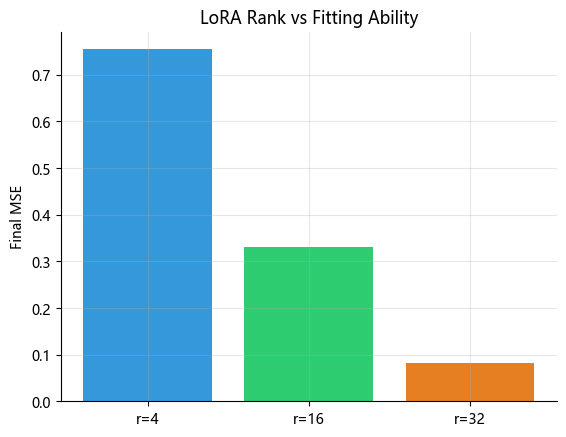

In [12]:
# 练习 2：对比不同 rank 的效果

torch.manual_seed(42)
X_train = torch.randn(200, 64)
W_true = torch.randn(64, 64) * 0.1
noise = torch.randn(200, 64) * 0.01
Y_train = X_train @ W_true + noise

ranks_to_test = [4, 16, 32]
results = {}

for r in ranks_to_test:
    # ↓↓↓ 你的代码 ↓↓↓
    lora = LoRALinear(64, 64, rank=r, alpha=r*2)
    optimizer = torch.optim.Adam(lora.parameters(), lr=0.01)
    for step in range(100):
        loss = F.mse_loss(lora(X_train), Y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    results[r] = loss.item()
    # ↑↑↑ 你的代码 ↑↑↑

# 验证
assert len(results) == 3, f"应有 3 个结果，得到 {len(results)}"
assert all(isinstance(v, float) for v in results.values())
print("All tests passed!")

plt.bar([f'r={r}' for r in ranks_to_test], [results[r] for r in ranks_to_test],
        color=['#3498db','#2ecc71','#e67e22'])
plt.ylabel('Final MSE'); plt.title('LoRA Rank vs Fitting Ability')
plt.show()

上面学到了 LoRA 的参数效率与 rank 的关系。接下来我们将学习**量化 (Quantization)** 技术——另一种节省显存的方法，并了解 QLoRA 如何将两者结合，让普通 GPU 也能微调大模型。

---
# Part 3：量化 + QLoRA：4-bit 微调术

## 什么是量化？

### 直觉理解

量化就像"降低照片分辨率"：原始照片（FP32）非常清晰但占空间大，压缩后的照片（INT8/INT4）略有模糊但小很多。关键是：对于大模型来说，这种"模糊"几乎不影响效果！

量化 (Quantization) 通过降低数值精度来缩减显存：

| 精度 | 字节/参数 | 7B 模型大小 | 相比 FP32 |
|------|----------|------------|----------|
| FP32 | 4 | 28 GB | 1x |
| FP16 | 2 | 14 GB | 2x 压缩 |
| INT8 | 1 | 7 GB | 4x 压缩 |
| INT4 | 0.5 | 3.5 GB | 8x 压缩 |

### 量化是怎么工作的？

```
原始值:    0.7532  (FP32, 32 bit)

INT8 量化:
  1. scale = max_val / 127 = 1.0/127 = 0.00787
  2. 量化:  round(0.7532 / 0.00787) = 96
  3. 存储:  96 (INT8, 8 bit)  → 节省 75% 显存
  4. 还原:  96 * 0.00787 = 0.7555
  5. 误差:  |0.7532 - 0.7555| = 0.0023  → 很小！

INT4 量化:
  误差更大，但能节省 87.5% 显存
```

> **QLoRA = INT4 量化 + LoRA**：用 4-bit 存储模型权重，只训练 LoRA 参数（FP16）。

In [13]:
# 量化实操演示
def quantize_tensor_symmetric(tensor, bits=8):
    """对称量化: 将浮点数映射到 [-q_max, q_max] 的整数范围"""
    max_val = tensor.abs().max()          # 找到绝对值最大值作为量化范围
    q_max = 2 ** (bits - 1) - 1           # 整数表示的最大值（如 INT8 = 127）
    scale = max_val / q_max               # 缩放因子 = 浮点范围 / 整数范围
    quantized = (tensor / scale).round().clamp(-q_max, q_max)  # 缩放+四舍五入+截断
    return quantized.to(torch.int8), scale

def dequantize_tensor(quantized, scale):
    """反量化: 将整数还原为浮点数（会有精度损失）"""
    return quantized.float() * scale

# 测试
original = torch.randn(512, 512)
print("量化对比")
print("=" * 50)

for bits in [8, 4]:
    q, scale = quantize_tensor_symmetric(original, bits)
    reconstructed = dequantize_tensor(q, scale)
    error = (original - reconstructed).abs()    # 量化误差 = |原始值 - 还原值|
    print(f"\n{bits}-bit 量化:")
    print(f"  原始大小:   {original.numel() * 4 / 1024:.1f} KB")
    print(f"  量化后大小: {q.numel() * (bits/8) / 1024:.1f} KB")
    print(f"  压缩比:     {32/bits:.1f}x")
    print(f"  平均误差:   {error.mean():.6f}")     # 误差越小，量化质量越高
    print(f"  最大误差:   {error.max():.6f}")

量化对比

8-bit 量化:
  原始大小:   1024.0 KB
  量化后大小: 256.0 KB
  压缩比:     4.0x
  平均误差:   0.009112
  最大误差:   0.018225

4-bit 量化:
  原始大小:   1024.0 KB
  量化后大小: 128.0 KB
  压缩比:     8.0x
  平均误差:   0.165277
  最大误差:   0.330648


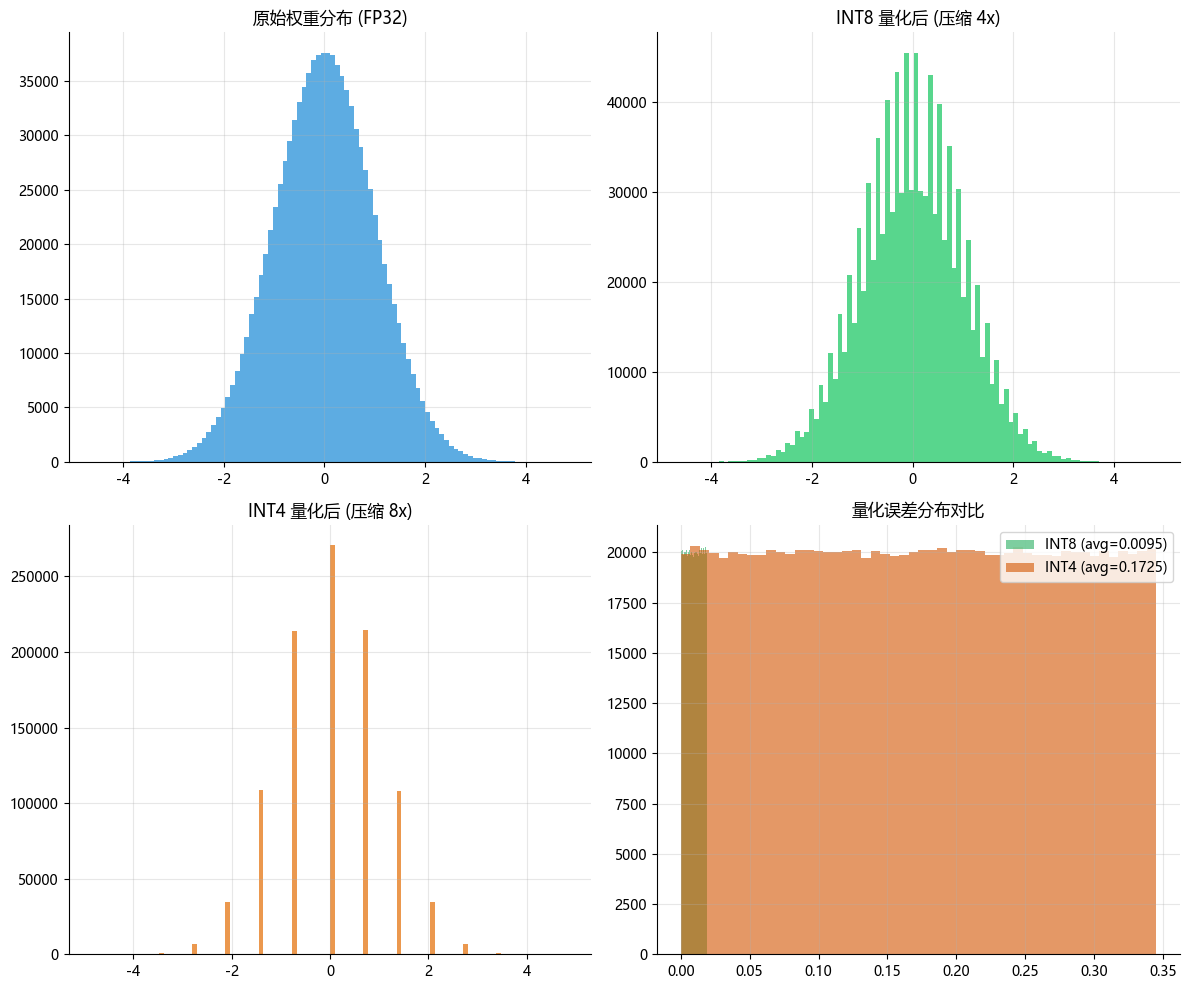

In [14]:
# 可视化量化效果
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
original = torch.randn(1000, 1000)

axes[0,0].hist(original.flatten().numpy(), bins=100, color='#3498db', alpha=0.8)
axes[0,0].set_title('原始权重分布 (FP32)')

q8, s8 = quantize_tensor_symmetric(original, 8)
r8 = dequantize_tensor(q8, s8)
axes[0,1].hist(r8.flatten().numpy(), bins=100, color='#2ecc71', alpha=0.8)
axes[0,1].set_title('INT8 量化后 (压缩 4x)')

q4, s4 = quantize_tensor_symmetric(original, 4)
r4 = dequantize_tensor(q4, s4)
axes[1,0].hist(r4.flatten().numpy(), bins=100, color='#e67e22', alpha=0.8)
axes[1,0].set_title('INT4 量化后 (压缩 8x)')

error_8 = (original - r8).abs().flatten().numpy()
error_4 = (original - r4).abs().flatten().numpy()
axes[1,1].hist(error_8, bins=50, alpha=0.6, label=f'INT8 (avg={error_8.mean():.4f})', color='#27ae60')
axes[1,1].hist(error_4, bins=50, alpha=0.6, label=f'INT4 (avg={error_4.mean():.4f})', color='#d35400')
axes[1,1].set_title('量化误差分布对比')
axes[1,1].legend()
plt.tight_layout(); plt.show()

⚠️ **注意：以下 QLoRA 代码仅作展示，不会在本环境中运行。**

QLoRA 依赖 `bitsandbytes` 库进行 4-bit 量化，该库目前**仅支持 Linux + NVIDIA GPU** 环境。在 Windows 或 macOS 上无法安装运行。我们展示这段代码是为了让大家了解 QLoRA 的实现方式——在实际生产中，你会在 Linux 服务器上使用它。

In [15]:
# QLoRA 配置示例
qlora_code = '''
# QLoRA Configuration (requires CUDA + bitsandbytes)
from transformers import BitsAndBytesConfig

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",       # NormalFloat4
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,   # 二次量化，进一步节省
)

model = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen2.5-7B",
    quantization_config=bnb_config,
    device_map="auto",
)
model = prepare_model_for_kbit_training(model)

lora_config = LoraConfig(r=16, lora_alpha=32, target_modules=["q_proj","v_proj"])
model = get_peft_model(model, lora_config)
'''
print(qlora_code)
print("\n" + "="*50)
print("QLoRA 显存需求估算（7B 模型）：")
print(f"  模型权重 (4-bit):  {7*0.5:.1f} GB")
print(f"  LoRA 参数 (FP16):  ~0.1 GB")
print(f"  优化器状态:        ~0.4 GB")
print(f"  总计:              ~4.0 GB  ← 单张 RTX 3060 可运行!")


# QLoRA Configuration (requires CUDA + bitsandbytes)
from transformers import BitsAndBytesConfig

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",       # NormalFloat4
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,   # 二次量化，进一步节省
)

model = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen2.5-7B",
    quantization_config=bnb_config,
    device_map="auto",
)
model = prepare_model_for_kbit_training(model)

lora_config = LoraConfig(r=16, lora_alpha=32, target_modules=["q_proj","v_proj"])
model = get_peft_model(model, lora_config)


QLoRA 显存需求估算（7B 模型）：
  模型权重 (4-bit):  3.5 GB
  LoRA 参数 (FP16):  ~0.1 GB
  优化器状态:        ~0.4 GB
  总计:              ~4.0 GB  ← 单张 RTX 3060 可运行!


---

## 练习 3：计算不同配置的 GPU 显存需求（10 分钟）⭐⭐ 进阶

计算不同微调配置下的 GPU 显存需求。

**任务：** 实现 `estimate_gpu_memory` 函数，返回各项显存及总计。

**提示：**
- 模型权重 = 参数量(B) x 字节/参数（结果直接为 GB）
- 梯度 = 可训练参数量(B) x 2 字节 (FP16)
- Adam 状态 = 可训练参数量(B) x 8 字节
- 激活值（粗估）= 模型权重 x 0.5

**预期输出：** 表格对比 Full FP16 / LoRA / QLoRA 显存

In [16]:
# 练习 3：计算 GPU 显存需求

def estimate_gpu_memory(
    num_params_billion: float,
    precision_bytes: float,
    trainable_ratio: float,
    optimizer: str = "adam",
) -> dict:
    """估算 GPU 显存需求（GB）"""
    # ↓↓↓ 你的代码 ↓↓↓
    model_gb = num_params_billion * precision_bytes
    trainable_params = num_params_billion * trainable_ratio
    gradient_gb = trainable_params * 2
    opt_multiplier = 8 if optimizer == "adam" else 4
    optimizer_gb = trainable_params * opt_multiplier
    activation_gb = model_gb * 0.5
    total = model_gb + gradient_gb + optimizer_gb + activation_gb
    return {'model': model_gb, 'gradient': gradient_gb, 'optimizer': optimizer_gb, 'activation': activation_gb, 'total': total}
    # ↑↑↑ 你的代码 ↑↑↑

# 验证
test_result = estimate_gpu_memory(7, 2, 1.0, "adam")
assert test_result is not None, "函数返回了 None"
assert 'total' in test_result, "返回 dict 缺少 'total' 键"
assert abs(test_result['model'] - 14.0) < 0.1, f"模型显存应为 14.0G，得到 {test_result['model']}"
print("All tests passed!")

scenarios = [
    {"name": "7B Full FP16",   "params": 7,  "prec": 2,   "ratio": 1.0},
    {"name": "7B LoRA FP16",   "params": 7,  "prec": 2,   "ratio": 0.01},
    {"name": "7B QLoRA INT4",  "params": 7,  "prec": 0.5, "ratio": 0.01},
    {"name": "13B QLoRA INT4", "params": 13, "prec": 0.5, "ratio": 0.005},
]

print(f"\n{'Scenario':<20} {'Model':>8} {'Grad':>8} {'Optim':>8} {'Act':>8} {'Total':>8}")
print("-" * 72)
for s in scenarios:
    result = estimate_gpu_memory(s["params"], s["prec"], s["ratio"])
    print(f"{s['name']:<20} {result['model']:>7.1f}G {result['gradient']:>7.1f}G "
          f"{result['optimizer']:>7.1f}G {result['activation']:>7.1f}G {result['total']:>7.1f}G")

All tests passed!

Scenario                Model     Grad    Optim      Act    Total
------------------------------------------------------------------------
7B Full FP16            14.0G    14.0G    56.0G     7.0G    91.0G
7B LoRA FP16            14.0G     0.1G     0.6G     7.0G    21.7G
7B QLoRA INT4            3.5G     0.1G     0.6G     1.8G     6.0G
13B QLoRA INT4           6.5G     0.1G     0.5G     3.2G    10.4G


到这里我们已经掌握了高效微调的核心技术：LoRA 减少训练参数，量化压缩模型体积，QLoRA 两者结合。但微调只解决了“能力”问题——模型还需要学会“行为规范”。下一步我们将学习 **DPO 对齐**，让模型学会什么样的回答是“好的”。

---
# Part 4：DPO 对齐 — "RLHF 太难？DPO 来了"

## 为什么需要对齐 (Alignment)？

### 直觉理解

SFT 微调就像教一个学生"怎么做题"，但他可能会：答案太啰嗦、抄袭课本原文、甚至给出有害建议。**对齐**就是额外教他"什么样的回答是好的"——不只会做题，还要做得漂亮、安全、符合要求。

SFT 微调后的模型有"能力"但缺乏"规范"：
- 可能回答冗长废话
- 可能生搬硬套有偏见
- 可能输出不安全内容

**对齐**：模型的输出要符合人类偏好。

## RLHF vs DPO 对比

| 维度 | RLHF (PPO) | DPO |
|------|-----------|-----|
| **流程** | 训练奖励模型 → PPO 强化学习 | 直接用偏好数据优化 |
| **需要几模型** | 3个（policy + reward + ref） | 2个（policy + ref） |
| **实现复杂度** | 很高（PPO 超参数多） | 低（类似 SFT） |
| **训练稳定性** | 不稳定，容易崩 | 稳定 |
| **效果** | 天花板略高 | 90%+ 场景足够 |
| **企业推荐** | 大团队、充裕算力 | **中小团队首选** |

> **结论：** 除非你是 OpenAI 级别团队，否则 DPO 是更实际的选择。

## DPO 核心公式

### 直觉理解

想象你在训练一个新员工回答客户问题。你给他看一组例子："这样回答是好的（chosen），那样回答是不好的（rejected）"。DPO 的训练过程就像这样——不需要单独训练一个"评分老师"（奖励模型），而是直接从好坏对比中学习。

类比：就像学生不用考试（RLHF），直接看"标准答案 vs 错误答案"的对比就能学会（DPO）。

**输入：** 偏好数据三元组 `(prompt, chosen, rejected)`

**目标：** 让模型更倾向生成 chosen，远离 rejected

$$\mathcal{L}_{DPO} = -\mathbb{E}\left[\log\sigma\left(\beta \left(\log\frac{\pi_\theta(y_w|x)}{\pi_{ref}(y_w|x)} - \log\frac{\pi_\theta(y_l|x)}{\pi_{ref}(y_l|x)}\right)\right)\right]$$

**逐项解读：**
- $\log\frac{\pi_\theta(y_w|x)}{\pi_{ref}(y_w|x)}$：chosen 的 log-ratio，希望增大（模型更偏好好回答）
- $\log\frac{\pi_\theta(y_l|x)}{\pi_{ref}(y_l|x)}$：rejected 的 log-ratio，希望减小（模型远离坏回答）
- $\beta$：控制偏离参考模型的程度（通常 0.1~0.5，太大会导致模型退化）
- $\sigma$：sigmoid，将差值映射到 (0,1)

In [17]:
# 偏好数据
PREFERENCE_DATA = [
    {"prompt": "中国的首都是哪里？", "chosen": "北京。", "rejected": "中国的首都是北京。北京是中华人民共和国的首都，位于华北平原北部，是中国的政治、文化和国际交流中心。"},
    {"prompt": "水的沸点是多少度？", "chosen": "100度（标准大气压下）。", "rejected": "水的沸点在标准大气压下是100摄氏度。当然这个数值会随着气压变化而变化，在高海拔地区由于气压较低水的沸点会相应降低。"},
    {"prompt": "1+1等于多少？", "chosen": "2。", "rejected": "1+1等于2。这是一个基础的数学运算，属于加法。在十进制数学体系中1加1的结果是2。"},
    {"prompt": "太阳从哪个方向升起？", "chosen": "东方。", "rejected": "太阳从东方升起。这是因为地球自西向东自转，所以我们在地球上看到太阳每天从东方升起从西方落下。"},
    {"prompt": "一年有多少天？", "chosen": "365天或366天。", "rejected": "一年通常有365天。但是每四年会有一个闰年，闰年有366天。闰年的判断规则是能被4整除但不能被100整除或者能被400整除。"},
    {"prompt": "Python中如何创建空列表？", "chosen": "[] 或 list()", "rejected": "在Python中创建一个空列表有两种方法。第一种是使用方括号 my_list = [] 这是最常用的方式。第二种是使用list函数 my_list = list()。"},
    {"prompt": "Git如何撤销最近一次commit？", "chosen": "git reset HEAD~1", "rejected": "要撤销最近一次commit你有几个选择。如果你想保留工作目录中的更改可以使用git reset --soft HEAD~1。如果你想完全丢弃更改可以使用git reset --hard HEAD~1。"},
    {"prompt": "什么是机器学习？", "chosen": "让计算机从数据中自动学习规律的技术。", "rejected": "机器学习是人工智能的一个分支，它是一种让计算机系统能够从数据中学习和改进的技术。机器学习算法通过分析大量数据来发现模式和规律然后利用这些模式来进行预测或决策。"},
    {"prompt": "怎么煮鸡蛋？", "chosen": "冷水下锅，水开后煮6-10分钟。", "rejected": "煮鸡蛋的步骤如下：首先将鸡蛋放入锅中加入冷水没过鸡蛋。然后开火加热等水烧开后开始计时。如果你喜欢溏心蛋煮6-7分钟，如果喜欢全熟煮10分钟。"},
    {"prompt": "光速是多少？", "chosen": "约30万公里/秒。", "rejected": "光在真空中的传播速度约为每秒299792458米，通常简化为每秒30万公里或每秒3乘以10的8次方米。"},
]

print(f"偏好数据集: {len(PREFERENCE_DATA)} 条")
print(f"\n示例:")
d = PREFERENCE_DATA[0]
print(f"  Prompt:   {d['prompt']}")
print(f"  Chosen:   {d['chosen']}")
print(f"  Rejected: {d['rejected'][:50]}...")

偏好数据集: 10 条

示例:
  Prompt:   中国的首都是哪里？
  Chosen:   北京。
  Rejected: 中国的首都是北京。北京是中华人民共和国的首都，位于华北平原北部，是中国的政治、文化和国际交流中心。...


In [18]:
# DPO Loss 实现
def dpo_loss(
    policy_chosen_logps: torch.Tensor,      # 策略模型对 chosen 的 log 概率
    policy_rejected_logps: torch.Tensor,    # 策略模型对 rejected 的 log 概率
    reference_chosen_logps: torch.Tensor,   # 参考模型对 chosen 的 log 概率
    reference_rejected_logps: torch.Tensor, # 参考模型对 rejected 的 log 概率
    beta: float = 0.1,                      # 控制偏离参考模型的程度
) -> Tuple[torch.Tensor, Dict[str, float]]:
    """计算 DPO 损失"""
    # 计算 log-ratio: 策略模型相对参考模型的概率比
    chosen_log_ratio = policy_chosen_logps - reference_chosen_logps     # chosen 的 log(π/π_ref)
    rejected_log_ratio = policy_rejected_logps - reference_rejected_logps  # rejected 的 log(π/π_ref)

    # 核心: chosen 的 ratio 应该大于 rejected 的 ratio
    log_ratio_diff = chosen_log_ratio - rejected_log_ratio
    losses = F.logsigmoid(beta * log_ratio_diff)   # sigmoid 将差值映射到 (0,1)
    loss = -losses.mean()                           # 取负号（最小化损失 = 最大化 chosen 偏好）

    # 监控指标（不参与梯度计算）
    with torch.no_grad():
        reward_margin = log_ratio_diff.mean().item()    # chosen 与 rejected 的奖励差距
        accuracy = (chosen_log_ratio > rejected_log_ratio).float().mean().item()  # 偏好准确率

    return loss, {'loss': loss.item(), 'reward_margin': reward_margin, 'accuracy': accuracy}

print("DPO loss function defined.")

# 简单验证: chosen 概率高于 rejected 时，loss 应该较小
p_c = torch.tensor([0.0])    # 策略模型对 chosen 的 log 概率
p_r = torch.tensor([-1.0])   # 策略模型对 rejected 的 log 概率（更低）
r_c = torch.tensor([0.0])    # 参考模型作为基准
r_r = torch.tensor([0.0])
l, m = dpo_loss(p_c, p_r, r_c, r_r, beta=0.1)
print(f"Test: loss={l.item():.4f}, margin={m['reward_margin']:.4f}, acc={m['accuracy']:.0%}")

DPO loss function defined.
Test: loss=0.6444, margin=1.0000, acc=100%


In [19]:
# DPO 模型加载与训练配置
DPO_MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"
MAX_SEQ_LEN = 256          # 最大序列长度
DPO_BETA = 0.1             # DPO 的 beta 参数（控制偏离参考模型的程度）
DPO_EPOCHS = 1
DPO_LR = 2e-6 if device == 'cpu' else 5e-6
DPO_BATCH_SIZE = 2 if device == 'cpu' else 4
TRAINABLE_LAYERS = 4       # 只训练最后 4 层（节省显存）

# 加载分词器
print(f"Loading {DPO_MODEL_NAME}...")
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    dpo_tokenizer = AutoTokenizer.from_pretrained(DPO_MODEL_NAME, trust_remote_code=True)
if dpo_tokenizer.pad_token is None:
    dpo_tokenizer.pad_token = dpo_tokenizer.eos_token

dtype = torch.bfloat16 if device == 'cuda' else torch.float32

# 加载两个模型: policy（会被训练）和 reference（冻结作为基准）
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    policy_model = AutoModelForCausalLM.from_pretrained(DPO_MODEL_NAME, dtype=dtype, trust_remote_code=True).to(device)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    reference_model = AutoModelForCausalLM.from_pretrained(DPO_MODEL_NAME, dtype=dtype, trust_remote_code=True).to(device)

# 冻结参考模型（策略模型对照训练）
reference_model.eval()
for p in reference_model.parameters(): p.requires_grad = False

# 策略模型: 先冻结全部，再解冻最后几层（部分微调，节省显存）
for p in policy_model.parameters(): p.requires_grad = False
for layer in policy_model.model.layers[-TRAINABLE_LAYERS:]:
    for p in layer.parameters(): p.requires_grad = True
for p in policy_model.lm_head.parameters(): p.requires_grad = True

trainable = sum(p.numel() for p in policy_model.parameters() if p.requires_grad)
total = sum(p.numel() for p in policy_model.parameters())
print(f"Loaded: {total:,} params, trainable: {trainable:,} ({trainable/total*100:.1f}%)")

Loading Qwen/Qwen2.5-0.5B-Instruct...


The following layers were not sharded: model.embed_tokens.weight, model.layers.*.input_layernorm.weight, model.norm.weight, lm_head.weight, model.layers.*.post_attention_layernorm.weight


The following layers were not sharded: model.embed_tokens.weight, model.layers.*.input_layernorm.weight, model.norm.weight, lm_head.weight, model.layers.*.post_attention_layernorm.weight


Loaded: 494,032,768 params, trainable: 195,784,192 (39.6%)


In [20]:
# DPO 辅助函数
def build_chat_prompt(msg):
    return dpo_tokenizer.apply_chat_template(
        [{"role": "user", "content": msg}], tokenize=False, add_generation_prompt=True)

def build_full_text(msg, resp):
    return dpo_tokenizer.apply_chat_template(
        [{"role": "user", "content": msg}, {"role": "assistant", "content": resp}],
        tokenize=False, add_generation_prompt=False)

def tokenize_text(text, max_length=MAX_SEQ_LEN, padding='max_length'):
    return dpo_tokenizer(text, max_length=max_length, padding=padding,
                         truncation=True, return_tensors='pt')

@torch.inference_mode()
def generate_response(model, prompt, max_new_tokens=100, temperature=0.0):
    inputs = tokenize_text(build_chat_prompt(prompt), padding=False).to(device)
    outputs = model.generate(**inputs, max_new_tokens=max_new_tokens,
                             temperature=temperature if temperature > 0 else None,
                             do_sample=temperature > 0,
                             pad_token_id=dpo_tokenizer.pad_token_id)
    return dpo_tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:],
                                skip_special_tokens=True).strip()

def compute_log_probs(model, input_ids, attention_mask, prompt_lengths, reduction="mean"):
    with torch.set_grad_enabled(model.training):
        logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
        shift_logits = logits[:, :-1, :]
        shift_labels = input_ids[:, 1:]
        shift_mask = attention_mask[:, 1:]
        log_probs = F.log_softmax(shift_logits.float(), dim=-1)
        token_log_probs = torch.gather(log_probs, dim=-1, index=shift_labels.unsqueeze(-1)).squeeze(-1)
        if not torch.is_tensor(prompt_lengths):
            prompt_lengths = torch.tensor(prompt_lengths)
        prompt_lengths = prompt_lengths.to(shift_mask.device)
        if prompt_lengths.dim() == 0:
            prompt_lengths = prompt_lengths.unsqueeze(0)
        seq_pos = torch.arange(shift_mask.size(1), device=shift_mask.device).unsqueeze(0)
        response_mask = (shift_mask * (seq_pos >= (prompt_lengths - 1).clamp(min=0).unsqueeze(1))).float()
        sum_lp = (token_log_probs * response_mask).sum(dim=-1)
        return sum_lp / response_mask.sum(dim=-1).clamp(min=1) if reduction == "mean" else sum_lp

print("Helper functions defined.")

Helper functions defined.


In [21]:
# DPO Dataset & Trainer
class DPODataset(Dataset):
    def __init__(self, data, tokenizer, max_length=MAX_SEQ_LEN):
        self.data, self.tokenizer, self.max_length = data, tokenizer, max_length
    def __len__(self): return len(self.data)
    def __getitem__(self, idx):
        item = self.data[idx]
        prompt_tokens = tokenize_text(build_chat_prompt(item['prompt']), padding=False)
        chosen_tokens = tokenize_text(build_full_text(item['prompt'], item['chosen']))
        rejected_tokens = tokenize_text(build_full_text(item['prompt'], item['rejected']))
        return {'prompt_length': prompt_tokens['input_ids'].shape[1],
                'chosen_input_ids': chosen_tokens['input_ids'].squeeze(0),
                'chosen_attention_mask': chosen_tokens['attention_mask'].squeeze(0),
                'rejected_input_ids': rejected_tokens['input_ids'].squeeze(0),
                'rejected_attention_mask': rejected_tokens['attention_mask'].squeeze(0)}

class DPOTrainer:
    def __init__(self, policy_model, reference_model, beta=0.1, lr=1e-5):
        self.policy_model, self.reference_model, self.beta = policy_model, reference_model, beta
        self.optimizer = torch.optim.AdamW(
            [p for p in policy_model.parameters() if p.requires_grad], lr=lr, weight_decay=0.01)
        self.history = {'loss': [], 'reward_margin': [], 'accuracy': []}

    def train_step(self, batch):
        self.policy_model.train()
        c_ids = batch['chosen_input_ids'].to(device)
        c_mask = batch['chosen_attention_mask'].to(device)
        r_ids = batch['rejected_input_ids'].to(device)
        r_mask = batch['rejected_attention_mask'].to(device)
        pl = batch['prompt_length'].to(device)

        pc = compute_log_probs(self.policy_model, c_ids, c_mask, pl)
        pr = compute_log_probs(self.policy_model, r_ids, r_mask, pl)
        with torch.no_grad():
            rc = compute_log_probs(self.reference_model, c_ids, c_mask, pl)
            rr = compute_log_probs(self.reference_model, r_ids, r_mask, pl)

        loss, metrics = dpo_loss(pc, pr, rc, rr, self.beta)
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.policy_model.parameters(), 1.0)
        self.optimizer.step()
        for k in self.history:
            self.history[k].append(metrics.get(k, 0))
        return metrics

    def train(self, dataset, batch_size=4, num_epochs=3, log_interval=5):
        loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
        print(f"DPO Training: {len(dataset)} examples, {num_epochs} epochs")
        step = 0
        for epoch in range(num_epochs):
            for batch in loader:
                metrics = self.train_step(batch)
                step += 1
                if step % log_interval == 0:
                    print(f"  Step {step:3d} | Loss: {metrics['loss']:.4f} | "
                          f"Margin: {metrics['reward_margin']:.4f} | Acc: {metrics['accuracy']:.0%}")
            print(f"  Epoch {epoch+1}/{num_epochs} done")

# 训练
dpo_dataset = DPODataset(PREFERENCE_DATA, dpo_tokenizer)
start_time = time.time()
trainer = DPOTrainer(policy_model, reference_model, beta=DPO_BETA, lr=DPO_LR)
trainer.train(dpo_dataset, batch_size=DPO_BATCH_SIZE, num_epochs=DPO_EPOCHS)
elapsed = time.time() - start_time
print(f"\nDone in {elapsed:.1f}s")

DPO Training: 10 examples, 1 epochs


  Step   5 | Loss: 0.6899 | Margin: 0.0661 | Acc: 100%
  Epoch 1/1 done

Done in 40.0s


---

## 练习 4：对比 DPO 训练前后的输出风格（10 分钟）⭐⭐ 进阶

训练已完成。对比 Reference 与 DPO 模型的输出差异。

**任务：**
1. 对每个测试问题，分别用两个模型生成回答
2. 实现偏好准确率函数 `eval_pref_acc`
3. 对比两模型的偏好准确率

**提示：**
- `generate_response(model, question)` 生成回答
- 偏好准确率：对每条数据，比较模型对 chosen/rejected 的 log-prob
- chosen 的 log_prob > rejected 则 correct += 1

**预期输出：** `Preference Accuracy: Ref=~50%, DPO=~70-90%`

In [22]:
# 练习 4：对比 DPO 训练前后的输出

TEST_QUESTIONS = [
    "中国的首都是哪里？",
    "什么是机器学习？",
    "日本的首都是哪里？",
    "什么是深度学习？",
    "HTTP是什么？",
]

# 步骤 1：生成对比
for q in TEST_QUESTIONS:
    # ↓↓↓ 你的代码 ↓↓↓
    ref_answer = generate_response(reference_model, q)
    dpo_answer = generate_response(policy_model, q)
    print(f"Q: {q}")
    print(f"  Ref: {ref_answer}")
    print(f"  DPO: {dpo_answer}")
    print()
    # ↑↑↑ 你的代码 ↑↑↑

# 步骤 2：偏好准确率
def eval_pref_acc(model, dataset):
    """计算模型对 chosen 的偏好准确率"""
    # ↓↓↓ 你的代码 ↓↓↓
    correct = 0
    total = len(dataset)
    model.eval()
    with torch.no_grad():
        for i in range(total):
            batch = dataset[i]
            c_ids = batch['chosen_input_ids'].unsqueeze(0).to(device)
            c_mask = batch['chosen_attention_mask'].unsqueeze(0).to(device)
            r_ids = batch['rejected_input_ids'].unsqueeze(0).to(device)
            r_mask = batch['rejected_attention_mask'].unsqueeze(0).to(device)
            pl = batch['prompt_length']
            chosen_lp = compute_log_probs(model, c_ids, c_mask, pl)
            rejected_lp = compute_log_probs(model, r_ids, r_mask, pl)
            if chosen_lp.item() > rejected_lp.item():
                correct += 1
    return correct / total
    # ↑↑↑ 你的代码 ↑↑↑

# 验证
ref_acc = eval_pref_acc(reference_model, dpo_dataset)
dpo_acc = eval_pref_acc(policy_model, dpo_dataset)
assert ref_acc is not None, "eval_pref_acc 返回了 None"
assert 0 <= ref_acc <= 1, f"准确率应在 0-1 之间，得到 {ref_acc}"
print(f"Preference Accuracy: Ref={ref_acc:.0%}, DPO={dpo_acc:.0%}")
print("All tests passed!")

The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Q: 中国的首都是哪里？
  Ref: 中国共有34个省级行政区，包括23个省、5个自治区、4个直辖市和2个特别行政区。其中，北京市是中华人民共和国的首都，位于中国东部，是中国最大的城市之一。

北京是中国的政治、经济、文化中心，也是国际交往的重要枢纽。它拥有丰富的历史文化遗产，如故宫、长城等，以及现代化的城市基础设施和现代设施。此外，北京还是全国科技创新中心、国家重要教育基地、国际交往中心等重要位置。
  DPO: 中国共有34个省级行政区，包括23个省、5个自治区、4个直辖市和2个特别行政区。其中，北京市是中华人民共和国的首都，位于中国东部，是中国最大的城市之一。

北京是中国的政治、经济、文化、交通、科研、教育等中心，也是世界著名的国际大都市。



Q: 什么是机器学习？
  Ref: 机器学习是一种人工智能的分支，它使计算机能够通过数据自动改进和优化其性能。简单来说，机器学习就是让计算机从数据中学习并从中做出决策或预测。

在机器学习中，算法被设计成可以从大量的训练数据中学习到模式，并使用这些模式来预测新的输入结果。这种能力使得机器学习能够在许多领域中发挥作用，包括自然语言处理、图像识别、推荐系统等。

机器学习的核心思想是“模型”（model），
  DPO: 机器学习是一种人工智能的分支，它使计算机能够通过数据自动改进和优化其性能。简单来说，就是让计算机从数据中学习并应用这些学习到的知识来做出预测或决策。

在机器学习中，算法被设计成可以从大量的训练数据中学习模式，并使用这些模型进行新的输入任务的预测。这包括分类、回归、聚类等任务，以及监督学习（如线性回归）、无监督学习（如K-means）和强化



Q: 日本的首都是哪里？
  Ref: 日本的首都是东京。
  DPO: 日本的首都是东京。



Q: 什么是深度学习？
  Ref: 深度学习是一种机器学习方法，它使用多层神经网络来模拟人脑的处理方式。这种技术通过大量的数据训练模型，使得计算机能够从复杂的数据中自动发现模式和规律，并进行预测或分类。

在深度学习中，通常会将输入数据分为多个特征维度（如图像、声音等），然后让模型通过这些特征维度对数据进行分析和建模。深度学习的核心思想是利用大量数据来训练模型，使模型能够在没有明确
  DPO: 深度学习是一种机器学习方法，它使用多层神经网络来模拟人脑的处理方式。这种技术通过大量的数据训练模型，使得计算机能够从复杂的数据中自动发现模式和规律，并进行预测或分类。

在深度学习中，通常会将输入数据分为多个特征维度（如图像、语音等），然后让模型通过这些特征对数据进行分析并提取出有用的特征。然后，模型可以利用这些特征进行复杂的计算和推理，从而实现各种



Q: HTTP是什么？
  Ref: HTTP（超文本传输协议）是互联网上用于在Web浏览器和服务器之间进行数据交换的一种标准。它是一种基于TCP/IP的通信协议，主要用于在网络上提供网页内容、文件下载以及浏览其他网站等服务。

HTTP的基本工作原理如下：

1. **请求与响应**：当用户访问一个网站时，他们发送一个HTTP请求到该网站的服务器端。这个请求包含了一段HTML文档或JavaScript代码，以及可能需要的数据。服务器收到请求后
  DPO: HTTP（超文本传输协议）是互联网上用于在Web浏览器和服务器之间进行数据交换的一种标准。它是一种基于TCP/IP的通信协议，主要用于在网络上提供网页内容、文件下载以及浏览其他网站等服务。

HTTP的基本工作原理如下：

1. **请求与响应**：当用户访问一个网站时，他们发送一个HTTP请求到该网站的服务器端。这个请求包含了一段HTML文档或JavaScript代码，以及可能需要的数据。服务器收到请求后



Preference Accuracy: Ref=10%, DPO=20%
All tests passed!


我们已经完成了从 LoRA 微调到 DPO 对齐的完整流程。但如何知道模型变好了多少呢？下一步我们将学习**模型评测**方法：PPL、基准测试和 LLM-as-a-Judge，帮你量化模型的进步。

---
# Part 5：模型评测

### 直觉理解

训练完模型后，怎么知道它变好了？就像考核员工一样，我们需要多种"考试"来全面评估：
- **PPL** 相当于"听写测验"——测试语言流畅度
- **基准测试** 相当于"标准化考试"——测试知识和推理
- **LLM-as-Judge** 相当于"面试"——让另一个强模型来打分
- **人工评测** 相当于"老板亲自评价"——最准确但最贵

## 评测方法总览

| 方法 | 测什么 | 优点 | 缺点 |
|------|---------|------|------|
| **PPL (困惑度)** | 语言建模能力 | 自动、便宜 | 不反映指令遵循能力 |
| **基准准确率** | 知识/推理能力 | 客观可比 | Benchmark 污染 |
| **LLM-as-Judge** | 综合质量 | 接近人类判断 | 有偏差、成本高 |
| **人工评测** | 金标准 | 最可靠 | 成本极高 |

### PPL 的局限性

| PPL 能衡量 | PPL 不能衡量 |
|-----------|-------------|
| 语法流畅度 | 指令遵循能力 |
| 词汇搭配自然度 | 事实准确性 |
| 上下文连贯性 | 回答正确性 |

In [23]:
# 1. Perplexity (PPL) 评测
# PPL 衡量模型对文本的"困惑程度"——越低说明模型越能预测下一个词

def calculate_perplexity(logits, targets):
    """PPL = exp(交叉熵损失)，值越低表示模型越好"""
    loss = F.cross_entropy(
        logits.view(-1, logits.size(-1)),   # 展平为 [total_tokens, vocab_size]
        targets.view(-1),                    # 展平为 [total_tokens]
        reduction='mean'
    )
    return torch.exp(loss).item()            # exp(loss) 就是 PPL

# 模拟演示
vocab_size = 1000
batch_size, seq_len = 2, 100

# 好模型：预测比较准确（给正确 token 更高的分数）
good_logits = torch.randn(batch_size, seq_len, vocab_size)
targets = torch.randint(0, vocab_size, (batch_size, seq_len))
good_logits.scatter_(-1, targets.unsqueeze(-1), 5.0)  # 给正确答案加分

# 差模型：随机预测
bad_logits = torch.randn(batch_size, seq_len, vocab_size)

ppl_good = calculate_perplexity(good_logits, targets)
ppl_bad = calculate_perplexity(bad_logits, targets)

print(f"好模型 PPL: {ppl_good:.2f}")    # 应该较低
print(f"差模型 PPL: {ppl_bad:.2f}")      # 应该接近 vocab_size
print(f"随机预测 PPL ≈ vocab_size = {vocab_size}")

好模型 PPL: 12.13
差模型 PPL: 1857.19
随机预测 PPL ≈ vocab_size = 1000


In [24]:
# 2. 任务准确率（模拟 MMLU）

def evaluate_mmlu_sample(model_answer, correct_answer):
    return model_answer.strip().upper() == correct_answer.strip().upper()

mmlu_samples = [
    {"question": "What is the capital of France?",
     "choices": ["A. London", "B. Paris", "C. Berlin", "D. Madrid"], "answer": "B"},
    {"question": "What is 2 + 2?",
     "choices": ["A. 3", "B. 4", "C. 5", "D. 6"], "answer": "B"},
    {"question": "Chemical symbol for water?",
     "choices": ["A. O2", "B. CO2", "C. H2O", "D. NaCl"], "answer": "C"},
]
model_answers = ["B", "B", "C"]

correct = sum(evaluate_mmlu_sample(ma, s["answer"]) for ma, s in zip(model_answers, mmlu_samples))
print(f"MMLU: {correct}/{len(mmlu_samples)} = {correct/len(mmlu_samples)*100:.1f}%")

# 模拟 GSM8K
def evaluate_gsm8k(model_answer, correct_answer):
    def extract_number(text):
        nums = re.findall(r'-?\d+\.?\d*', text)
        return float(nums[-1]) if nums else None
    m, c = extract_number(model_answer), extract_number(correct_answer)
    return m is not None and c is not None and abs(m - c) < 0.01

gsm8k_samples = [
    {"q": "John has 5 apples, gives 2 to Mary. How many left?", "a": "3"},
    {"q": "A car travels 60 km/h for 3 hours. Distance?", "a": "180"},
]
gsm8k_answers = ["5 - 2 = 3 apples.", "60 * 3 = 180 km"]
correct = sum(evaluate_gsm8k(ma, s["a"]) for ma, s in zip(gsm8k_answers, gsm8k_samples))
print(f"GSM8K: {correct}/{len(gsm8k_samples)} = {correct/len(gsm8k_samples)*100:.1f}%")

MMLU: 3/3 = 100.0%
GSM8K: 2/2 = 100.0%


In [25]:
# 3. LLM-as-a-Judge

def llm_judge_prompt(question, response_a, response_b):
    return f"""Please evaluate the following two responses.

Question: {question}

Response A: {response_a}
Response B: {response_b}

Compare based on: Helpfulness, Accuracy, Clarity.
Output: "A", "B", or "Tie"

Your judgment:"""

# 示例
prompt = llm_judge_prompt(
    "How do I learn Python?",
    "Read the docs.",
    "Start with basics like variables and loops. Practice with small projects."
)
print("LLM Judge Prompt:")
print("=" * 50)
print(prompt)
print("\n(在实际中，将此 prompt 发送给 GPT-4 或其他强模型)")

# 模拟多次评测结果
judgments = ["B", "B", "A", "B", "Tie", "B", "B", "A", "B", "B"]
counts = defaultdict(int)
for j in judgments: counts[j] += 1
total = len(judgments)
print(f"\nLLM-as-a-Judge 结果:")
for k, v in sorted(counts.items()):
    print(f"  {k}: {v/total*100:.1f}%")

LLM Judge Prompt:
Please evaluate the following two responses.

Question: How do I learn Python?

Response A: Read the docs.
Response B: Start with basics like variables and loops. Practice with small projects.

Compare based on: Helpfulness, Accuracy, Clarity.
Output: "A", "B", or "Tie"

Your judgment:

(在实际中，将此 prompt 发送给 GPT-4 或其他强模型)

LLM-as-a-Judge 结果:
  A: 20.0%
  B: 70.0%
  Tie: 10.0%


评测结果:
  PPL: 43.7086
  MMLU: 0.7124
  GSM8K: 0.5498
  HumanEval: 0.4498


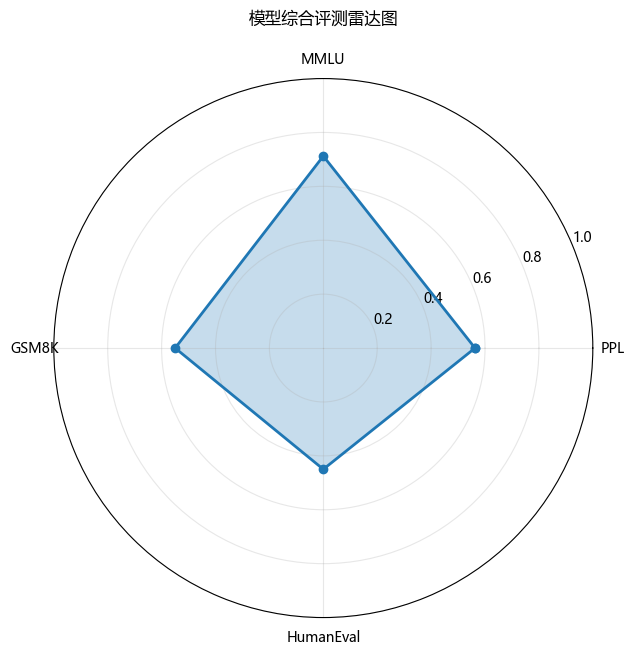

In [26]:
# 4. 综合评测框架

class ModelEvaluator:
    def __init__(self):
        self.results = {}

    def evaluate_perplexity(self, model=None, test_data=None):
        np.random.seed(42)
        ppl = np.random.uniform(10, 100)
        self.results['PPL'] = ppl
        return ppl

    def evaluate_mmlu(self, model=None, data=None):
        np.random.seed(42)
        acc = np.random.uniform(0.6, 0.9)
        self.results['MMLU'] = acc
        return acc

    def evaluate_gsm8k(self, model=None, data=None):
        np.random.seed(42)
        acc = np.random.uniform(0.4, 0.8)
        self.results['GSM8K'] = acc
        return acc

    def evaluate_humaneval(self, model=None, data=None):
        np.random.seed(42)
        rate = np.random.uniform(0.3, 0.7)
        self.results['HumanEval'] = rate
        return rate

    def plot_radar(self):
        cats = list(self.results.keys())
        vals = list(self.results.values())
        normalized = [1 - v/100 if 'PPL' in c else v for c, v in zip(cats, vals)]
        angles = np.linspace(0, 2*np.pi, len(cats), endpoint=False).tolist()
        normalized += normalized[:1]
        angles += angles[:1]
        fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
        ax.plot(angles, normalized, 'o-', linewidth=2)
        ax.fill(angles, normalized, alpha=0.25)
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(cats)
        ax.set_ylim(0, 1)
        plt.title('模型综合评测雷达图', pad=20)
        plt.show()

# 运行评测
evaluator = ModelEvaluator()
evaluator.evaluate_perplexity()
evaluator.evaluate_mmlu()
evaluator.evaluate_gsm8k()
evaluator.evaluate_humaneval()

print("评测结果:")
for k, v in evaluator.results.items():
    print(f"  {k}: {v:.4f}")
evaluator.plot_radar()

---

## 练习 5：自己计算评测指标（15 分钟）⭐⭐⭐ 挑战

从 (prediction, reference) 文本对计算评测指标。

**任务：**
1. 实现 `compute_exact_match(preds, refs)` -- 精确匹配率
2. 实现 `compute_f1_token_overlap(pred, ref)` -- token 级 F1 分数
3. 应用到模型输出上，对比两个指标

**提示：**

精确匹配：统计 pred == ref 的比例。

F1 计算步骤：
1. 将 pred 和 ref 转为字符集合
2. 计算交集大小 common
3. precision = common / len(pred 字符集合)
4. recall = common / len(ref 字符集合)
5. F1 = 2 * precision * recall / (precision + recall)
6. 注意分母为 0 时返回 0.0

**预期输出：** 精确匹配率与平均 F1 对比表 + 柱状图

#    预测             参考           EM     F1
------------------------------------------
1    产品质量问题         产品质量          0   0.80
2    物流配送           物流配送          1   1.00
3    售后服务相关         售后服务          0   0.80
4    关于价格的争议        价格争议          0   0.73
5    账户问题           账户问题          1   1.00
6    产品质量           产品质量          1   1.00
7    物流延迟问题         物流配送          0   0.40
8    售后             售后服务          0   0.67
9    价格争议           价格争议          1   1.00
10   账户安全问题         账户问题          0   0.80
------------------------------------------
精确匹配率: 40.0%, 平均F1: 81.9%


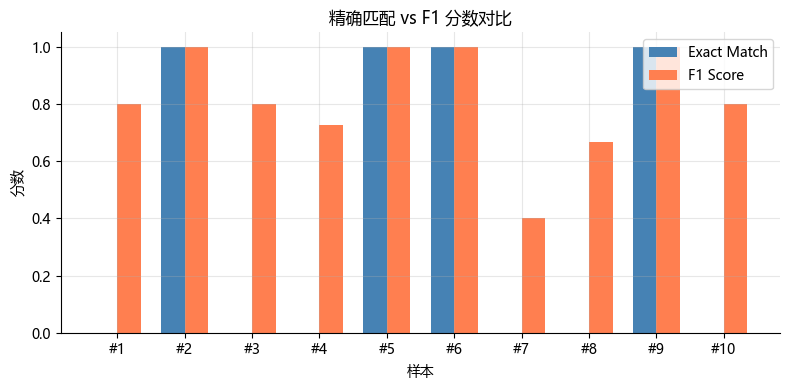


All tests passed!


In [27]:
# 练习 5：自己计算评测指标

# 模拟数据：模型预测 vs 参考答案
eval_pairs = [
    ("产品质量问题", "产品质量"),
    ("物流配送", "物流配送"),
    ("售后服务相关", "售后服务"),
    ("关于价格的争议", "价格争议"),
    ("账户问题", "账户问题"),
    ("产品质量", "产品质量"),
    ("物流延迟问题", "物流配送"),
    ("售后", "售后服务"),
    ("价格争议", "价格争议"),
    ("账户安全问题", "账户问题"),
]

predictions = [p[0] for p in eval_pairs]
references = [p[1] for p in eval_pairs]

def compute_exact_match(preds, refs):
    """精确匹配率：预测完全等于参考的比例，返回 0~1"""
    # ↓↓↓ 你的代码 ↓↓↓
    # 统计 pred == ref 的数量，除以总数
    matches = sum(1 for p, r in zip(preds, refs) if p == r)
    return matches / len(preds)
    # ↑↑↑ 你的代码 ↑↑↑

def compute_f1_token_overlap(pred, ref):
    """字符级 F1 分数：衡量预测与参考的字符重叠程度，返回 0~1"""
    # ↓↓↓ 你的代码 ↓↓↓
    # 1. 将 pred 和 ref 转为字符集合
    # 2. 求交集大小
    # 3. precision = 交集 / 预测字符数
    # 4. recall = 交集 / 参考字符数
    # 5. F1 = 2*p*r / (p+r)，分母为 0 时返回 0.0
    pred_chars = set(pred)
    ref_chars = set(ref)
    common = pred_chars & ref_chars
    if len(pred_chars) == 0 or len(ref_chars) == 0:
        return 0.0
    precision = len(common) / len(pred_chars)
    recall = len(common) / len(ref_chars)
    if precision + recall == 0:
        return 0.0
    return 2 * precision * recall / (precision + recall)
    # ↑↑↑ 你的代码 ↑↑↑

# 计算所有样本的指标
print(f"{'#':<4} {'预测':<14} {'参考':<10} {'EM':>4} {'F1':>6}")
print("-" * 42)
em_scores = []
f1_scores = []
for i, (pred, ref) in enumerate(zip(predictions, references)):
    em = 1 if pred == ref else 0
    f1 = compute_f1_token_overlap(pred, ref)
    if f1 is not None:
        em_scores.append(em)
        f1_scores.append(f1)
        print(f"{i+1:<4} {pred:<14} {ref:<10} {em:>4} {f1:>6.2f}")

if em_scores and f1_scores:
    avg_em = sum(em_scores) / len(em_scores)
    avg_f1 = sum(f1_scores) / len(f1_scores)
    print("-" * 42)
    print(f"精确匹配率: {avg_em*100:.1f}%, 平均F1: {avg_f1*100:.1f}%")

    fig, ax = plt.subplots(figsize=(8, 4))
    x = range(len(em_scores))
    width = 0.35
    ax.bar([i - width/2 for i in x], em_scores, width, label='Exact Match', color='steelblue')
    ax.bar([i + width/2 for i in x], f1_scores, width, label='F1 Score', color='coral')
    ax.set_xlabel('样本')
    ax.set_ylabel('分数')
    ax.set_title('精确匹配 vs F1 分数对比')
    ax.legend()
    ax.set_xticks(list(x))
    ax.set_xticklabels([f'#{i+1}' for i in x])
    plt.tight_layout()
    plt.show()

# 验证
em_result = compute_exact_match(["A", "B", "C"], ["A", "B", "D"])
assert em_result is not None, "compute_exact_match 返回了 None"
assert abs(em_result - 2/3) < 0.01, f"精确匹配率应为 0.667，得到 {em_result}"

f1_result = compute_f1_token_overlap("产品质量问题", "产品质量")
assert f1_result is not None, "compute_f1_token_overlap 返回了 None"
assert 0 < f1_result < 1, f"F1 应在 0-1 之间，得到 {f1_result}"
print("\nAll tests passed!")

掌握了评测方法后，最后一步是将所有知识综合起来做**企业级决策**：选什么模型、用什么微调方法、成本怎么算。下一步我们将进入实战决策环节。

---

# Part 6：企业决策 — 模型选型与成本分析

## 开源模型选型指南

| 模型系列 | 代表规格 | 中文能力 | 代码能力 | 推荐场景 |
|---------|---------|:------:|:------:|---------|
| **Qwen2.5** | 0.5B/1.5B/7B/14B/72B | 优秀 | 优秀 | 中文场景首选 |
| **Llama 3** | 8B/70B | 一般 | 良好 | 英文为主，社区生态好 |
| **Mistral** | 7B/8x7B (MoE) | 一般 | 良好 | 性价比高，MoE 架构 |
| **DeepSeek** | 7B/67B/MoE | 优秀 | 极佳 | 代码/数学场景 |
| **GLM-4** | 9B | 优秀 | 良好 | 中文对话场景 |

## 微调 vs API 决策流程

```
你的场景需要定制化吗？
  ├── 否 → 直接用 API（GPT-4/Claude/通义千问）
  └── 是 → 数据量有多少？
        ├── < 100 条 → Few-shot + Prompt Engineering
        ├── 100-10K 条 → LoRA / QLoRA 微调
        └── > 10K 条 → 考虑全量微调
              └── 数据是否包含偏好？
                    ├── 是 → 加上 DPO 对齐
                    └── 否 → 纯 SFT 即可
```

## 成本分析框架

| 方案 | 一次性成本 | 月度成本 | 适合场景 |
|------|----------|---------|----------|
| **API 调用** | 0 | $0.01-0.06/1K tokens | 低量、探索期 |
| **QLoRA 7B** | ~$50 (A100 4h) | 推理 ~$200/月 | 中等量，需定制 |
| **Full FT 7B** | ~$500 (8xA100 1天) | 推理 ~$200/月 | 大量数据 |
| **部署 70B** | ~$2000 (训练) | ~$2000/月 (4xA100) | 高质量要求 |

In [28]:
# 成本计算器 —— API 调用 vs 自部署，哪个更划算？

def calculate_break_even(
    api_cost_per_1k_tokens: float,     # API 每 1000 tokens 的价格
    avg_tokens_per_request: int,       # 每次请求的平均 token 数
    daily_requests: int,               # 每日请求量
    finetune_cost: float,              # 一次性微调成本
    monthly_inference_cost: float,     # 自部署的月度运行成本
) -> dict:
    """计算 API vs 自部署的盈亏平衡点"""
    monthly_requests = daily_requests * 30
    monthly_api_cost = monthly_requests * avg_tokens_per_request / 1000 * api_cost_per_1k_tokens
    monthly_self_cost = monthly_inference_cost  # 不含一次性成本

    # 如果 API 更便宜，直接推荐 API
    if monthly_api_cost <= monthly_self_cost:
        return {"recommendation": "API", "monthly_api": monthly_api_cost,
                "monthly_self": monthly_self_cost, "break_even_months": float('inf')}

    # 计算多少个月能收回微调成本
    savings_per_month = monthly_api_cost - monthly_self_cost
    break_even_months = finetune_cost / savings_per_month if savings_per_month > 0 else float('inf')

    return {"recommendation": "自部署" if break_even_months < 6 else "API (观望)",
            "monthly_api": monthly_api_cost, "monthly_self": monthly_self_cost,
            "break_even_months": break_even_months}

# 三种典型场景对比
scenarios = [
    {"name": "小型客服Bot", "api_cost": 0.03, "tokens": 500, "daily": 100,
     "ft_cost": 50, "infer_cost": 200},
    {"name": "中型内容审核", "api_cost": 0.03, "tokens": 1000, "daily": 1000,
     "ft_cost": 200, "infer_cost": 400},
    {"name": "大型数据处理", "api_cost": 0.03, "tokens": 800, "daily": 10000,
     "ft_cost": 500, "infer_cost": 800},
]

print(f"{'场景':<16} {'月API费':>10} {'月自部署':>10} {'盈亏平衡':>10} {'建议':>12}")
print("-" * 62)
for s in scenarios:
    r = calculate_break_even(s["api_cost"], s["tokens"], s["daily"], s["ft_cost"], s["infer_cost"])
    be = f"{r['break_even_months']:.1f}月" if r['break_even_months'] < 100 else "N/A"
    print(f"{s['name']:<16} ${r['monthly_api']:>8.0f} ${r['monthly_self']:>8.0f} {be:>10} {r['recommendation']:>12}")

场景                    月API费       月自部署       盈亏平衡           建议
--------------------------------------------------------------
小型客服Bot          $      45 $     200        N/A          API
中型内容审核           $     900 $     400       0.4月          自部署
大型数据处理           $    7200 $     800       0.1月          自部署


---

## 练习 6：给定场景，选微调策略并估成本（10 分钟）⭐ 入门

**场景：** 一家电商公司想部署中文客服 AI 助手：
- 日均请求量：5000 次
- 平均每次请求：约 600 tokens
- 有 3000 条标注客服对话 + 500 条偏好数据
- 预算：首月 $2000 以内
- 要求：符合公司风格

**任务：**
1. 选择基座模型并说明理由
2. 确定微调策略（SFT / DPO / QLoRA 等）
3. 估算训练成本和月推理成本
4. 与 API 方案对比，计算盈亏平衡点

**提示：**
- 月 API 成本 = 日请求 x 平均 token / 1000 x 单价 x 30
- 盈亏平衡月数 = 训练成本 / (月 API 成本 - 月推理成本)

**预期输出：** 企业客服 AI 决策报告

In [29]:
# 练习 6：商业决策分析

# ↓↓↓ 你的代码 ↓↓↓

# 步骤 1：模型选择
model_choice = "Qwen2.5-7B"
reason = "7B模型在客服场景下性能足够，且推理成本较低，适合企业部署"

# 步骤 2：微调策略
strategy = "QLoRA SFT + DPO"

# 步骤 3：成本估算
training_cost = 500
monthly_inference = 200

# 步骤 4：与 API 对比
api_cost_per_1k = 0.03
daily_requests = 5000
avg_tokens = 500

monthly_api = daily_requests * avg_tokens / 1000 * api_cost_per_1k * 30
break_even = training_cost / (monthly_api - monthly_inference)

# ↑↑↑ 你的代码 ↑↑↑

# 打印决策报告
print("=" * 50)
print("企业客服 AI 决策报告")
print("=" * 50)
print(f"模型选择: {model_choice}")
print(f"理由: {reason}")
print(f"微调策略: {strategy}")
print(f"训练成本: ${training_cost}")
print(f"月运行成本: ${monthly_inference}")
print(f"月API成本: ${monthly_api:.0f}")
print(f"盈亏平衡: {break_even:.2f} 月")
print(f"\n结论: 自部署每月节省 ${monthly_api - monthly_inference:.0f}")

# 验证
assert model_choice is not None, "请填写模型选择"
assert monthly_api > 0, "月 API 成本应大于 0"
assert break_even > 0, "盈亏平衡月数应大于 0"
print("\nAll tests passed!")

企业客服 AI 决策报告
模型选择: Qwen2.5-7B
理由: 7B模型在客服场景下性能足够，且推理成本较低，适合企业部署
微调策略: QLoRA SFT + DPO
训练成本: $500
月运行成本: $200
月API成本: $2250
盈亏平衡: 0.24 月

结论: 自部署每月节省 $2050

All tests passed!


---

# Day 2 总结

## 今日知识图谱

```
┌─────────────────────────────────────────────────────────────┐
│                      Day 2 完整路线                          │
├──────────────┬──────────────┬───────────────┬───────────────┤
│   上午 SFT    │  下午 LoRA   │  下午 DPO     │  下午评测     │
│              │              │               │               │
│ 监督微调      │ 参数高效微调  │ 偏好对齐      │ 模型评估      │
│ 全量参数      │ 0.1% 参数    │ chosen/rejected│ PPL/MMLU     │
│              │ QLoRA 4-bit  │ 无需奖励模型   │ LLM-as-Judge │
└──────┬───────┴──────┬───────┴───────┬───────┴───────┬───────┘
       │              │               │               │
       ▼              ▼               ▼               ▼
  模型能做事     低成本微调       输出更对味      知道好不好
```

## 关键公式速查

| 名称 | 公式 | 说明 |
|------|------|------|
| LoRA | $y = Wx + BAx \cdot \frac{\alpha}{r}$ | 低秩适配 |
| DPO Loss | $-\log\sigma(\beta(\Delta_{chosen} - \Delta_{rejected}))$ | 偏好优化 |
| PPL | $\exp(-\frac{1}{N}\sum\log P(w_i))$ | 困惑度 |

## 企业决策核心

> **数据量 < 10K？用 QLoRA。有偏好数据？加 DPO。日请求 > 1000？自部署比 API 便宜。**

---

**明天 Day 3 预告：** Agent、RAG、部署优化 — 把模型变成产品！